# 12. So sánh Toàn diện Các Mô hình Tuned (Stats vs DL vs Tree)

Notebook này tổng hợp và đánh giá màn trình diễn trên tập Test của tất cả các mô hình đã được tinh chỉnh, qua đó tìm ra ứng viên tốt nhất.

In [1]:
import pandas as pd
import numpy as np
import pickle
import json
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import mean_squared_error, mean_absolute_error
from pathlib import Path

# Change CWD to project root
if Path.cwd().name == 'notebooks':
    os.chdir('..')

# Đảm bảo thư mục tồn tại
Path('outputs/figures').mkdir(parents=True, exist_ok=True)

def mape(y_true, y_pred):
    mask = y_true > 1e-6
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def regression_metrics(y_true, y_pred):
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MAPE': mape(y_true, y_pred)
    }

## 1. Nạp Dự báo (Test Set) của Tất cả Các Nhóm

In [4]:
# 1. Đọc Y Test (Ground Truth)
print("Loading test data...")
try:
    test_df = pd.read_csv('data/processed_R/modeling_fs/test_dl.csv')
except:
    test_df = pd.read_csv('data/processed/modeling_fs/test_dl.csv')

# Lưu ý: Target ban đầu đang ở dải log, ta convert lại về real units
y_test = test_df['target_pm25_h24_log'].dropna().values
y_test_real = np.expm1(y_test)

metrics_list = []
preds_dict = {}

# 2. Nạp Thống Kê (Stats) - Pickle này đã được lưu thẳng ra scale gốc (Real Units)
print("Loading Stats predictions...")
with open('outputs/predictions/tuned_stats_preds_real_units.pkl', 'rb') as f:
    stats_preds = pickle.load(f)
    for model_name, v in stats_preds.items():
        if isinstance(v, dict) and 'test' in v:
            pred_real = v['test']
            preds_dict[model_name.upper()] = pred_real
            m = regression_metrics(y_test_real, pred_real)
            metrics_list.append({'Model': model_name.upper(), 'Group': 'Stats', **m})

# 3. Nạp Deep Learning (GRU/LSTM) - Các file này lưu ở scale Log Transform
print("Loading DL predictions...")
with open('outputs/predictions/tuned_dl_preds.pkl', 'rb') as f:
    dl_preds = pickle.load(f)
    for k, v in dl_preds.items():
        if isinstance(v, dict) and 'test' in v:
            pred_real = np.expm1(v['test'])
            
            # Đổi tên "tuned_dl" cho chuẩn xác hơn
            model_disp_name = "GRU_Tuned"
            if 'params' in v and 'rnn_type' in v['params']:
                model_disp_name = f"{v['params']['rnn_type']}_Tuned"
                if v['params'].get('bidirectional'):
                    model_disp_name = f"Bi{model_disp_name}"
            
            preds_dict[model_disp_name] = pred_real
            m = regression_metrics(y_test_real, pred_real)
            metrics_list.append({'Model': model_disp_name, 'Group': 'DL', **m})

# 4. Nạp Tree Models (RF/XGB/LGB) - Đọc dự báo từ pipeline R do Notebook 11 chưa cache Tree Preds
# Lưu ý: Các Tree models bên R được train trực tiếp trên scale gốc (target_pm25_h24), KHÔNG convert expm1!
print("Loading Tree predictions...")
with open('outputs/predictions/tuned_tree_preds.pkl', 'rb') as f:
    tree_preds = pickle.load(f)
    for k, v in tree_preds.items():
        if not (isinstance(v, dict) and 'test' in v):
            continue
        pred_real = np.array(v['test'])
        preds_dict[k] = pred_real
        m = regression_metrics(y_test_real, pred_real)
        metrics_list.append({'Model': k, 'Group': 'Tree', **m})

# Compile DataFrame
results_df = pd.DataFrame(metrics_list)
print("Load hoàn tất!")

Loading test data...
Loading Stats predictions...
Loading DL predictions...
Loading Tree predictions...
Load hoàn tất!


## 2. Leaderboard: So Sánh Độ Chính Xác Các Nhóm

In [6]:
display(results_df.round(4).sort_values('RMSE').reset_index(drop=True))

,Model,Group,RMSE,MAE,MAPE
0,XGB_Tuned,Tree,17.7314,12.7045,36.3460
1,LGB_Tuned,Tree,17.9749,12.8980,36.8652
2,BiGRU_Tuned,DL,18.1584,12.3992,30.7941
3,SARIMAX,Stats,18.4015,13.0000,33.9237
4,SARIMA,Stats,18.4073,12.8484,33.5653
5,ARIMAX,Stats,18.7481,13.3565,34.9438
6,ARIMA,Stats,18.7806,13.2547,34.7830
7,RF_Tuned,Tree,18.7939,13.3883,38.7185


## 3. Trực Quan Hóa Đánh Giá

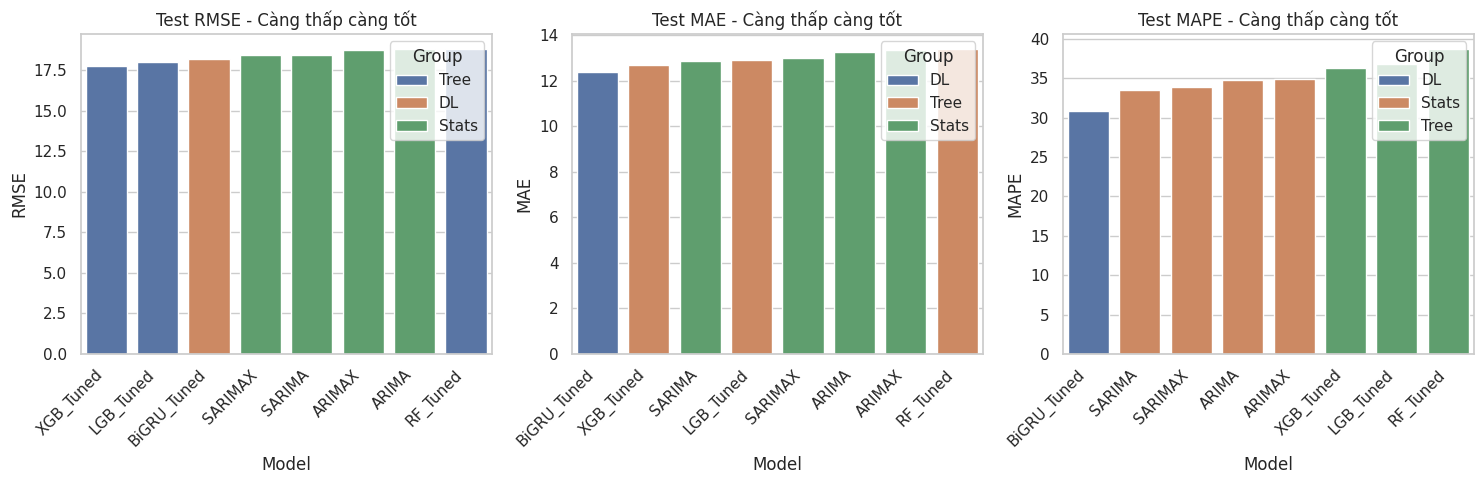

In [7]:
# Plotting Metrics
plt.figure(figsize=(15, 5))
sns.set_theme(style="whitegrid")
for i, metric in enumerate(['RMSE', 'MAE', 'MAPE'], 1):
    plt.subplot(1, 3, i)
    sns.barplot(data=results_df.sort_values(metric), x='Model', y=metric, hue='Group', dodge=False)
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Test {metric} - Càng thấp càng tốt')
plt.tight_layout()
plt.savefig('outputs/figures/all_models_comparison_metrics.png', dpi=150)
plt.show()

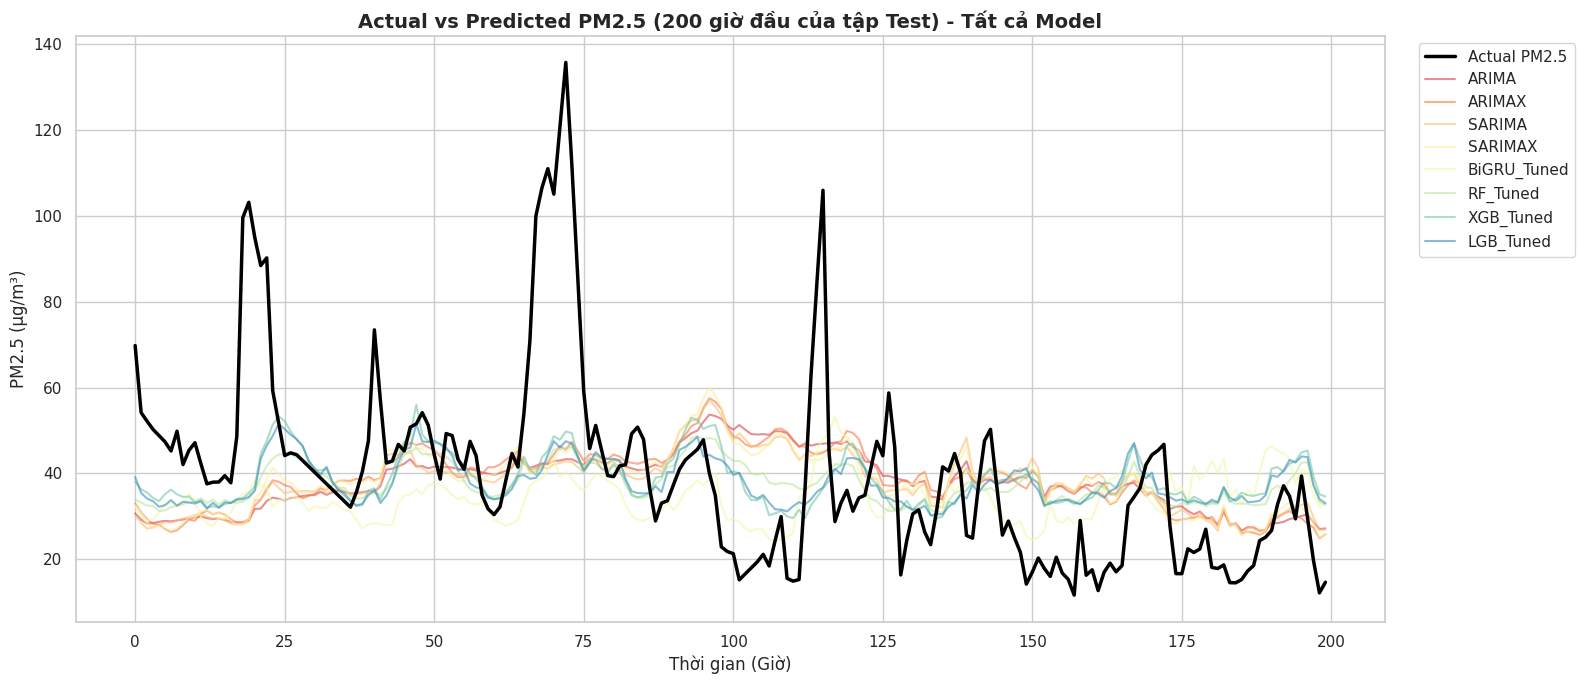

In [8]:
# Plotting Time Series
plt.figure(figsize=(16, 7))
subset_size = 200 # Chỉ vẽ 200 giờ đầu để dễ nhìn
plt.plot(y_test_real[:subset_size], label='Actual PM2.5', color='black', linewidth=2.5, zorder=10)

colors = sns.color_palette('Spectral', len(preds_dict))
for idx, (model_name, preds) in enumerate(preds_dict.items()):
    plt.plot(preds[:subset_size], label=model_name, alpha=0.6, color=colors[idx], linewidth=1.5)

plt.title('Actual vs Predicted PM2.5 (200 giờ đầu của tập Test) - Tất cả Model', fontsize=14, fontweight='bold')
plt.ylabel('PM2.5 (µg/m³)', fontsize=12)
plt.xlabel('Thời gian (Giờ)', fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('outputs/figures/all_models_comparison_ts.png', dpi=150)
plt.show()